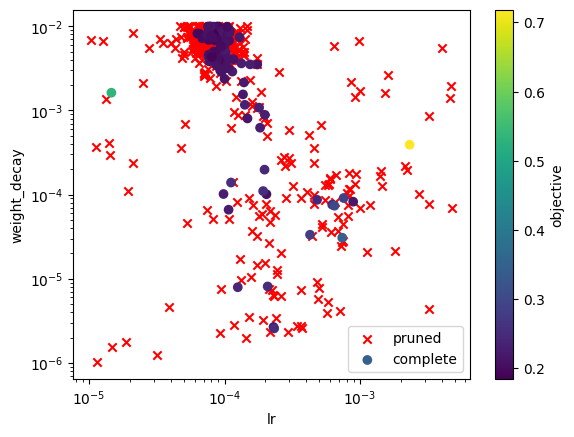

In [6]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from optuna.trial import TrialState

study = optuna.load_study(study_name="transformer_final_sweep", storage="sqlite:///studies/optuna_final_sweep.db")

trials = study.get_trials(deepcopy=False)

complete = [t for t in trials if t.state == TrialState.COMPLETE]
pruned = [t for t in trials if t.state == TrialState.PRUNED]

x_param = "lr"
y_param = "weight_decay"

def extract(trials):
    xs, ys, vals = [], [], []
    for t in trials:
        if x_param in t.params and y_param in t.params:
            xs.append(t.params[x_param])
            ys.append(t.params[y_param])
            vals.append(t.value if t.value is not None else None)
    return xs, ys, vals

cx, cy, cv = extract(complete)
px, py, _ = extract(pruned)

plt.scatter(px, py, c="red", marker="x", label="pruned")
plt.scatter(cx, cy, c=cv, cmap="viridis", label="complete")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(x_param)
plt.ylabel(y_param)
plt.legend()
plt.colorbar(label="objective")
plt.show()